In [ ]:
# -- 3.1 --

In [14]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

In [17]:
fits_files = [
    "../../course_assignments/homework10/M13_0001.fits",
    "../../course_assignments/homework10/M13_0002.fits",
    "../../course_assignments/homework10/M13_0003.fits",
    "../../course_assignments/homework10/M13_0004.fits",
    "../../course_assignments/homework10/M13_0005.fits"
]

In [18]:
all_data = []
all_headers = []

for file in fits_files:
    with fits.open(file) as hdul:
        header = hdul[0].header
        data = hdul[0].data
        
        all_headers.append(header)
        all_data.append(data)


In [20]:
# -- 3.2 --

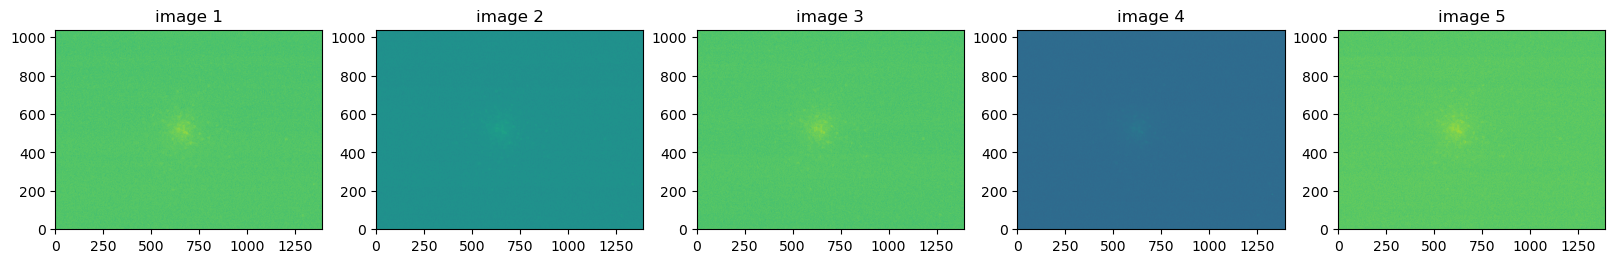

In [30]:
fig, axes = plt.subplots(1, 5, figsize=(20, 10))

for i in range(5):
    axes[i].imshow(all_data[i], origin="lower")
    axes[i].set_title(f"image {i+1}")

plt.show()

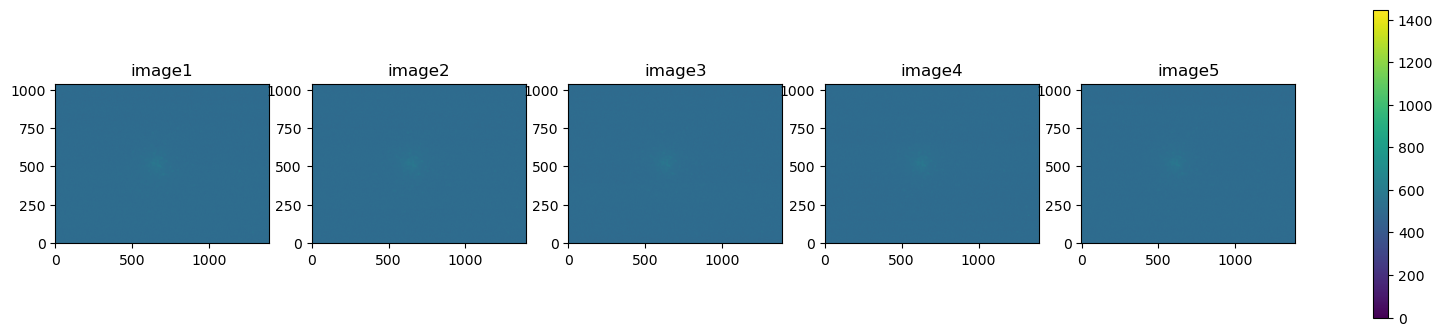

In [33]:
vmin = min(data.min() for data in all_data)
vmax = max(data.max() for data in all_data)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    im = axes[i].imshow(all_data[i], origin="lower", vmin=vmin, vmax=vmax)
    axes[i].set_title(f"image{i+1}")

fig.colorbar(im, ax=axes)
plt.show()

In the first set of plots, each image uses its own color scale, so each image is adjusted separately and is more clear.

The second set of plots use the same color scale for all five images. This makes the brightness values easier to compare directly, but the images look darker and less detailed.

In [ ]:
# -- 3.3 --

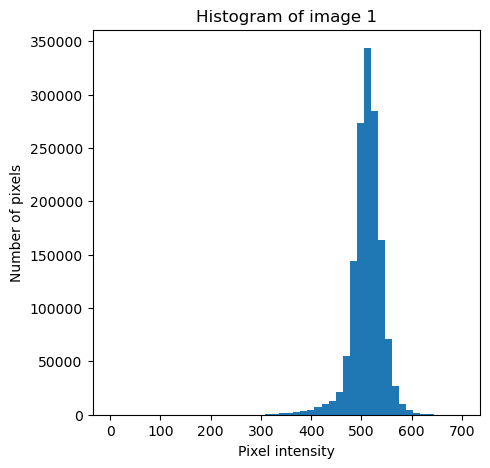

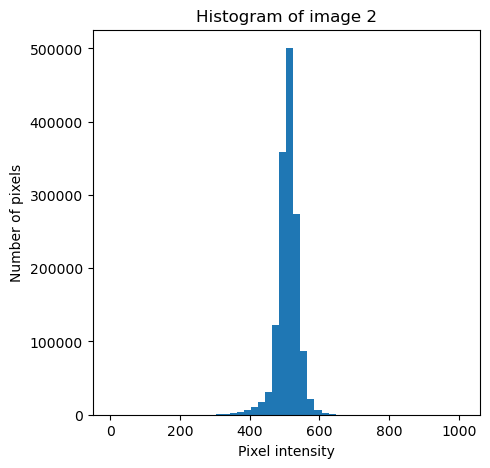

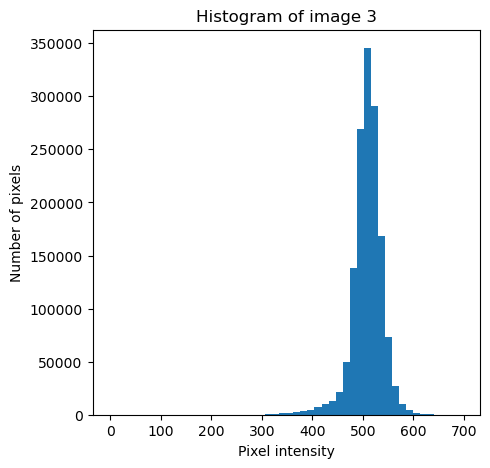

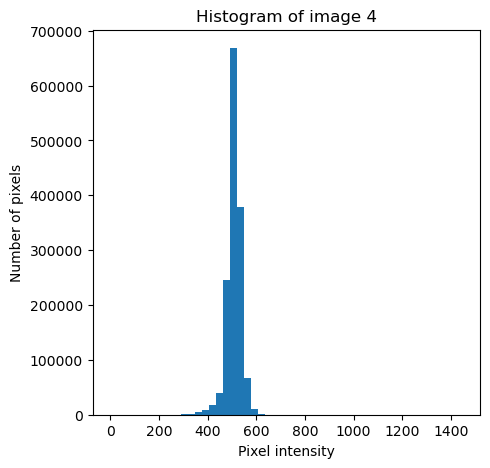

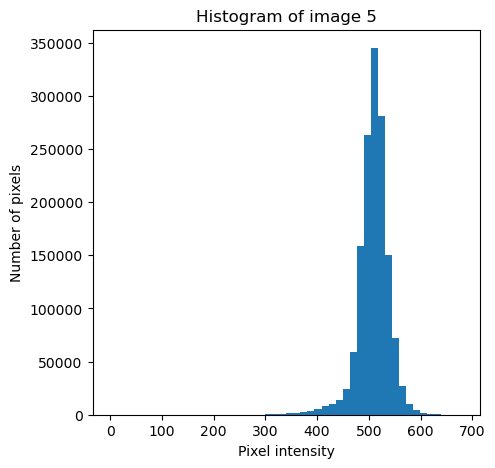

In [35]:
for i in range(5):
    plt.figure(figsize=(5,5))
    plt.hist(all_data[i].ravel(), bins=50)
    plt.title(f"Histogram of image {i+1}")
    plt.xlabel("Pixel intensity")
    plt.ylabel("Number of pixels")
    plt.show()


(a)
The x-axis shows the pixel intensity values. The y-axis shows the number of pixels with those intensity values.

(b)
bin=50 means that the pixel intensity values are divided into 50 intervals.

(c)
Most of the data is centered around pixel intensity where the histogram is at the tallest peak.

(d)
Most of the pixel values are not very spread out. They are concentrated near the main peak.

(e)
Mean and median are shown below

In [37]:
for i in range(5):
    mean = np.mean(all_data[i])
    median = np.median(all_data[i])
    
    print(f"image {i+1}")
    print("mean:", mean)
    print("median:", median)
    print()

image 1
mean: 510.4706668600796
median: 512.0

image 2
mean: 509.7460150033157
median: 511.0

image 3
mean: 508.0498729000884
median: 510.0

image 4
mean: 507.90583554376656
median: 509.0

image 5
mean: 508.7919920148099
median: 510.0



In [38]:
# -- 3.4 --

In [39]:
Combined = np.median(all_data, axis=0)

print("new median pixel intensity:", np.median(Combined))

new median pixel intensity: 510.0


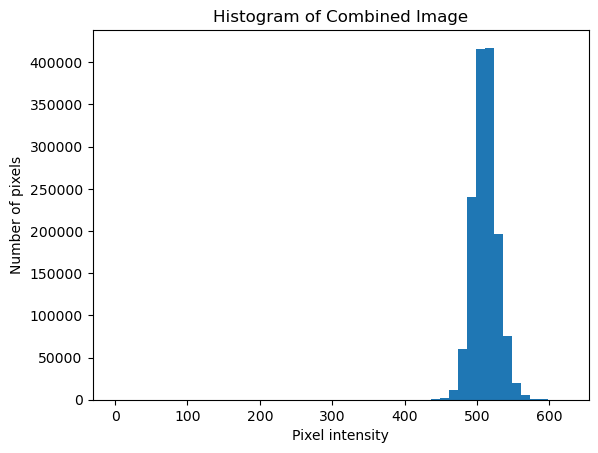

In [42]:
plt.hist(Combined.ravel(), bins=50)
plt.title("Histogram of Combined Image")
plt.xlabel("Pixel intensity")
plt.ylabel("Number of pixels")
plt.show()

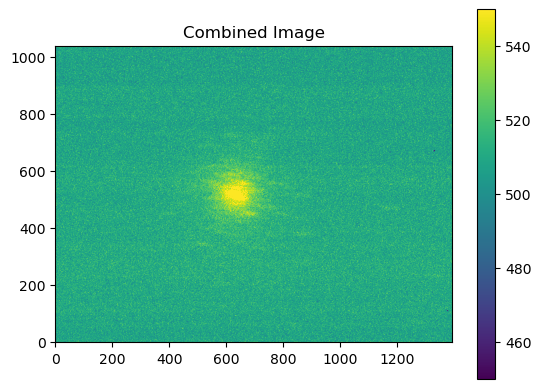

In [43]:
vmin = 450
vmax = 550

plt.imshow(Combined, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar()
plt.title("Combined Image")
plt.show()

The new combined image looks clearer and the central object is easier to see.

In [44]:
fits.writeto("combined.fits", Combined, overwrite=True)